# Capstone — Initial Data Exploratory Analysis

**Purpose:** Analyse the provided initial `.npy` observations for all 8 black-box functions before making strategy decisions. This notebook documents the evidence behind the kernel choices, acquisition function selections and β/ξ settings recorded in `MODEL_CARD.md`.

**Data source:** `initial_data/function_*/initial_inputs.npy` and `initial_data/function_*/initial_outputs.npy`

**Week 1 portal submissions** are overlaid on each plot to show how the first query compared to the initial data.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

# Load initial data
sys.path.insert(0, str(Path('..').resolve()))
from initial_data.load_all_functions import load_all_functions

data = load_all_functions(Path('..') / 'initial_data')

# Week 1 portal submissions and results
WEEK1 = {
    1: {'X': [0.999247, 0.985647],                                              'Y': 1.47e-185},
    2: {'X': [0.115878, 0.884079],                                              'Y': 0.025882},
    3: {'X': [0.778655, 0.249003, 0.41851],                                     'Y': -0.041700},
    4: {'X': [0.438110, 0.032583, 0.981555, 0.372065],                          'Y': -21.253811},
    5: {'X': [0.816816, 0.085090, 0.386806, 0.716711],                          'Y': 50.439619},
    6: {'X': [0.834917, 0.531385, 0.123811, 0.512032, 0.474771],                'Y': -1.825720},
    7: {'X': [0.333, 0.310, 0.250, 0.800, 0.800, 0.050],                        'Y': 0.120682},
    8: {'X': [0.241537, 0.754347, 0.171428, 0.086557, 0.351128, 0.974082, 0.194979, 0.655785], 'Y': 9.259667},
}

FN_LABELS = {
    1: '2D Contamination Field',
    2: '2D Noisy Log-Likelihood',
    3: '3D Drug Compounds',
    4: '4D Warehouse Hyperparams',
    5: '4D Chemical Yield',
    6: '5D Cake Recipe',
    7: '6D GBM Hyperparams',
    8: '8D ML Hyperparams',
}

COLORS = ['#00d4ff','#7c3aed','#10b981','#f59e0b','#ef4444','#ec4899','#8b5cf6','#06b6d4']

plt.style.use('dark_background')
plt.rcParams.update({'figure.facecolor': '#0a0e1a', 'axes.facecolor': '#111827',
                     'axes.edgecolor': '#1e2d45', 'grid.color': '#1e2d45',
                     'text.color': '#e2e8f0', 'axes.labelcolor': '#94a3b8',
                     'xtick.color': '#64748b', 'ytick.color': '#64748b',
                     'font.family': 'monospace', 'axes.titlesize': 11})

print('Data loaded:')
for fn_key, d in data.items():
    fn_id = int(fn_key.split('_')[1])
    print(f'  F{fn_id}: {d["inputs"].shape[0]} points, {d["inputs"].shape[1]}D, '
          f'Y ∈ [{d["outputs"].min():.4g}, {d["outputs"].max():.4g}]')

Data loaded:
  F1: 10 points, 2D, Y ∈ [-0.003606, 7.711e-16]
  F2: 10 points, 2D, Y ∈ [-0.06562, 0.6112]
  F3: 15 points, 3D, Y ∈ [-0.3989, -0.03484]
  F4: 30 points, 4D, Y ∈ [-32.63, -4.026]
  F5: 20 points, 4D, Y ∈ [0.1129, 1089]
  F6: 20 points, 5D, Y ∈ [-2.571, -0.7143]
  F7: 30 points, 6D, Y ∈ [0.002701, 1.365]
  F8: 40 points, 8D, Y ∈ [5.592, 9.598]


## 1. Output Distribution Across All Functions

Understanding the Y range, spread and shape for each function informs:
- Whether outputs are all negative (maximising toward 0) or positive
- How much variation exists (narrow range = easier to improve incrementally)
- Whether the distribution is uniform or skewed (skew suggests a small high-value region)

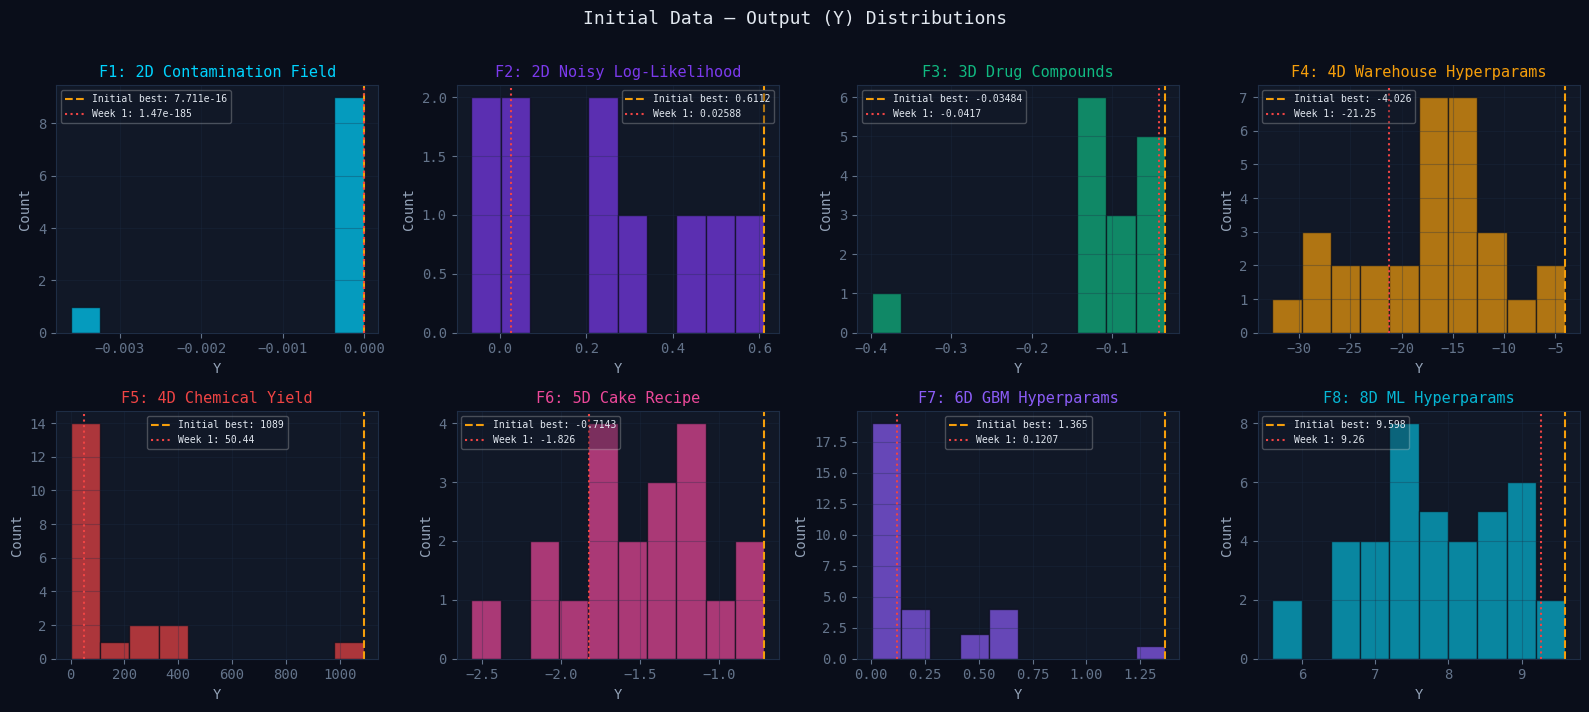

Saved: 01_y_distributions.png


In [2]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Initial Data — Output (Y) Distributions', fontsize=13, color='#e2e8f0', y=1.01)

for idx, (fn_key, d) in enumerate(sorted(data.items(), key=lambda x: int(x[0].split('_')[1]))):
    fn_id = int(fn_key.split('_')[1])
    ax = axes[idx // 4][idx % 4]
    Y = d['outputs']
    color = COLORS[fn_id - 1]
    w1_y = WEEK1[fn_id]['Y']

    ax.hist(Y, bins=min(10, len(Y)), color=color, alpha=0.7, edgecolor='#0a0e1a')
    ax.axvline(Y.max(), color='#f59e0b', lw=1.5, ls='--', label=f'Initial best: {Y.max():.4g}')
    ax.axvline(w1_y, color='#ef4444', lw=1.5, ls=':', label=f'Week 1: {w1_y:.4g}')
    ax.set_title(f'F{fn_id}: {FN_LABELS[fn_id]}', color=color, pad=6)
    ax.set_xlabel('Y')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7, framealpha=0.3)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_y_distributions.png', dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print('Saved: 01_y_distributions.png')

## 2. Summary Statistics Table

Structured comparison of all 8 functions including week 1 portal result vs initial best.

In [3]:
rows = []
for fn_key, d in sorted(data.items(), key=lambda x: int(x[0].split('_')[1])):
    fn_id = int(fn_key.split('_')[1])
    Y = d['outputs']
    w1 = WEEK1[fn_id]
    best_idx = int(np.argmax(Y))
    rows.append({
        'Function': f'F{fn_id}',
        'Description': FN_LABELS[fn_id],
        'Dims': d['inputs'].shape[1],
        'N (initial)': len(Y),
        'Y min': round(float(Y.min()), 6),
        'Y max': round(float(Y.max()), 6),
        'Y mean': round(float(Y.mean()), 6),
        'Y std': round(float(Y.std()), 6),
        'Best initial X': [round(v, 4) for v in d['inputs'][best_idx].tolist()],
        'Week 1 Y': round(w1['Y'], 6),
        'W1 vs best': 'IMPROVED' if w1['Y'] > Y.max() else f'{((w1["Y"] - Y.max()) / abs(Y.max()) * 100):.1f}%',
    })

df = pd.DataFrame(rows)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 60)
print(df[['Function','Description','Dims','N (initial)','Y min','Y max','Y mean','Y std','Week 1 Y','W1 vs best']].to_string(index=False))

Function              Description  Dims  N (initial)      Y min       Y max     Y mean      Y std   Week 1 Y W1 vs best
      F1   2D Contamination Field     2           10  -0.003606    0.000000  -0.000361   0.001082   0.000000    -100.0%
      F2  2D Noisy Log-Likelihood     2           10  -0.065624    0.611205   0.230674   0.225365   0.025882     -95.8%
      F3        3D Drug Compounds     3           15  -0.398926   -0.034835  -0.107167   0.084214  -0.041700     -19.7%
      F4 4D Warehouse Hyperparams     4           30 -32.625660   -4.025542 -17.238587   7.017985 -21.253811    -428.0%
      F5        4D Chemical Yield     4           20   0.112940 1088.859618 151.271876 245.575981  50.439619     -95.4%
      F6           5D Cake Recipe     5           20  -2.571170   -0.714265  -1.495390   0.449000  -1.825720    -155.6%
      F7       6D GBM Hyperparams     6           30   0.002701    1.364968   0.219607   0.302129   0.120682     -91.2%
      F8        8D ML Hyperparams     8 

## 3. Functions 1 & 2 — 2D Spatial Heatmaps

For 2D functions the full input space is visualisable. The heatmap shows which regions of the (X₁, X₂) space have been sampled and at what output value. Crucially for **Function 1**, this reveals which quadrants remain unsampled — the hotspot must be in one of them.

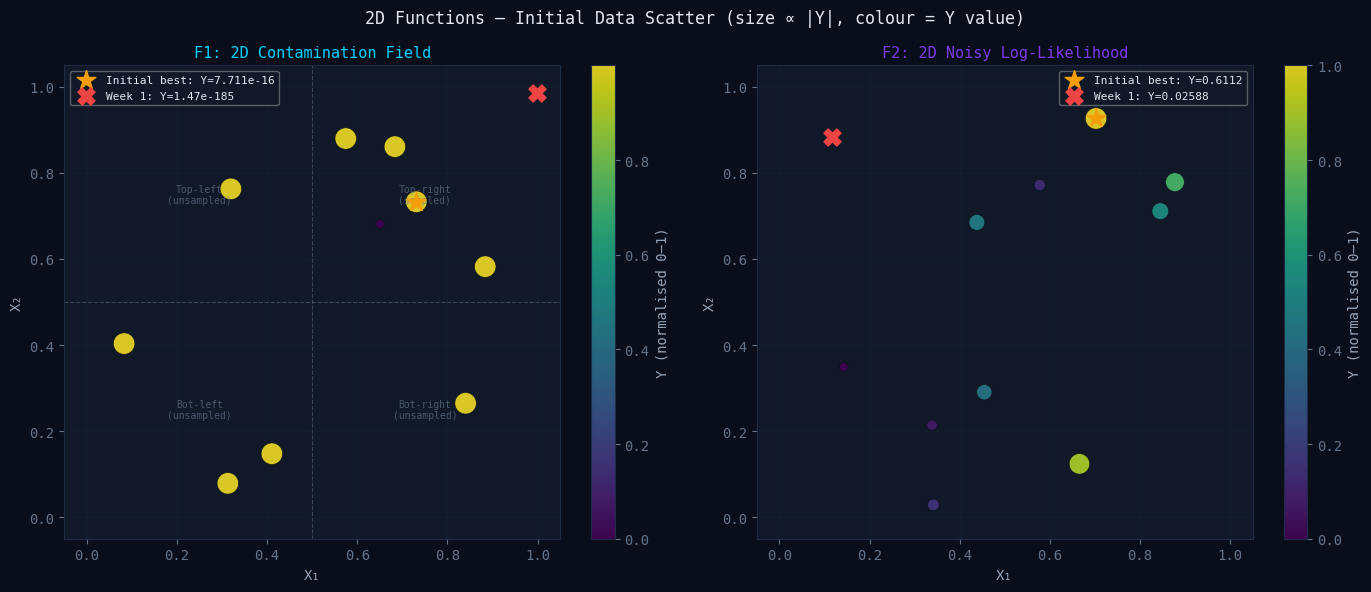

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('2D Functions — Initial Data Scatter (size ∝ |Y|, colour = Y value)', 
             fontsize=12, color='#e2e8f0')

for ax, fn_id in zip(axes, [1, 2]):
    fn_key = f'function_{fn_id}'
    d = data[fn_key]
    X, Y = d['inputs'], d['outputs']
    w1 = WEEK1[fn_id]
    color = COLORS[fn_id - 1]

    # Normalise Y for colour mapping
    y_norm = (Y - Y.min()) / (Y.max() - Y.min() + 1e-12)
    sizes = 40 + 200 * y_norm

    sc = ax.scatter(X[:, 0], X[:, 1], c=y_norm, cmap='viridis',
                    s=sizes, alpha=0.85, edgecolors='#0a0e1a', linewidth=0.5, zorder=3)

    # Mark best initial
    best_idx = int(np.argmax(Y))
    ax.scatter(X[best_idx, 0], X[best_idx, 1], s=200, marker='*',
               color='#f59e0b', zorder=5, label=f'Initial best: Y={Y[best_idx]:.4g}')

    # Mark week 1 submission
    ax.scatter(w1['X'][0], w1['X'][1], s=150, marker='X',
               color='#ef4444', zorder=5, label=f'Week 1: Y={w1["Y"]:.4g}')

    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('X₁')
    ax.set_ylabel('X₂')
    ax.set_title(f'F{fn_id}: {FN_LABELS[fn_id]}', color=color)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=8, framealpha=0.4)
    plt.colorbar(sc, ax=ax, label='Y (normalised 0–1)')

    # Annotate quadrant coverage for F1
    if fn_id == 1:
        ax.axvline(0.5, color='#64748b', lw=0.8, ls='--', alpha=0.5)
        ax.axhline(0.5, color='#64748b', lw=0.8, ls='--', alpha=0.5)
        for qx, qy, label in [(0.25, 0.75, 'Top-left\n(unsampled)'),
                               (0.75, 0.75, 'Top-right\n(sampled)'),
                               (0.25, 0.25, 'Bot-left\n(unsampled)'),
                               (0.75, 0.25, 'Bot-right\n(unsampled)')]:
            ax.text(qx, qy, label, ha='center', va='center', fontsize=7,
                    color='#64748b', alpha=0.7)

plt.tight_layout()
plt.savefig('02_2d_spatial_heatmaps.png', dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()

## 4. Function 3 — 3D Drug Compounds

Pairwise scatter plots for each pair of input dimensions, coloured by output Y. Reveals which compound combinations drive the output.

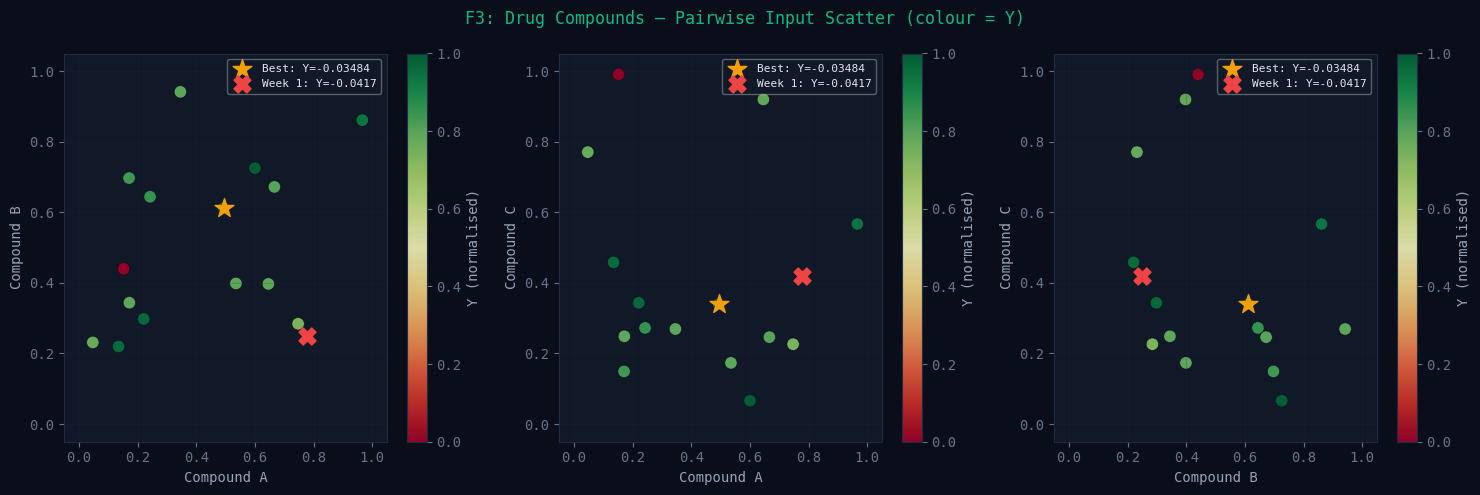

In [5]:
d3 = data['function_3']
X3, Y3 = d3['inputs'], d3['outputs']
dim_labels = ['Compound A', 'Compound B', 'Compound C']
w1_3 = WEEK1[3]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('F3: Drug Compounds — Pairwise Input Scatter (colour = Y)', 
             fontsize=12, color='#10b981')

pairs = [(0,1), (0,2), (1,2)]
y_norm3 = (Y3 - Y3.min()) / (Y3.max() - Y3.min() + 1e-12)
best_idx3 = int(np.argmax(Y3))

for ax, (i, j) in zip(axes, pairs):
    sc = ax.scatter(X3[:, i], X3[:, j], c=y_norm3, cmap='RdYlGn',
                    s=80, alpha=0.85, edgecolors='#0a0e1a', linewidth=0.5)
    ax.scatter(X3[best_idx3, i], X3[best_idx3, j], s=200, marker='*',
               color='#f59e0b', zorder=5, label=f'Best: Y={Y3[best_idx3]:.4g}')
    ax.scatter(w1_3['X'][i], w1_3['X'][j], s=150, marker='X',
               color='#ef4444', zorder=5, label=f'Week 1: Y={w1_3["Y"]:.4g}')
    ax.set_xlabel(dim_labels[i])
    ax.set_ylabel(dim_labels[j])
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=8, framealpha=0.4)
    plt.colorbar(sc, ax=ax, label='Y (normalised)')

plt.tight_layout()
plt.savefig('03_f3_pairwise.png', dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()

## 5. Input–Output Correlations for Higher-Dimensional Functions (F4–F8)

For functions with 4–8 dimensions we cannot visualise the full space. Pearson correlation between each input dimension and the output Y reveals which dimensions are most predictive of performance. High correlation → that dimension is a strong lever. Low correlation → less important, or a non-linear relationship exists.

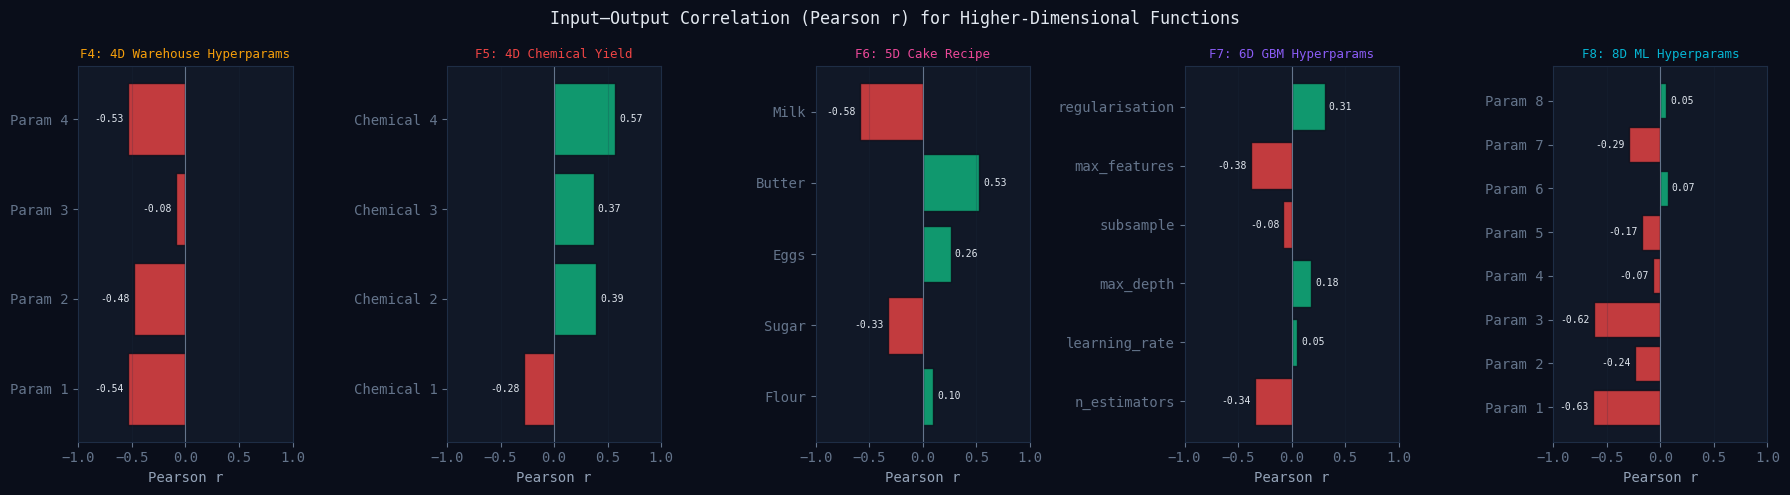

In [6]:
FN_DIM_LABELS = {
    4: ['Param 1', 'Param 2', 'Param 3', 'Param 4'],
    5: ['Chemical 1', 'Chemical 2', 'Chemical 3', 'Chemical 4'],
    6: ['Flour', 'Sugar', 'Eggs', 'Butter', 'Milk'],
    7: ['n_estimators', 'learning_rate', 'max_depth', 'subsample', 'max_features', 'regularisation'],
    8: [f'Param {i+1}' for i in range(8)],
}

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Input–Output Correlation (Pearson r) for Higher-Dimensional Functions',
             fontsize=12, color='#e2e8f0')

for ax, fn_id in zip(axes, [4, 5, 6, 7, 8]):
    fn_key = f'function_{fn_id}'
    d = data[fn_key]
    X, Y = d['inputs'], d['outputs']
    labels = FN_DIM_LABELS[fn_id]
    color = COLORS[fn_id - 1]

    corrs = [float(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])]
    bar_colors = ['#10b981' if c > 0 else '#ef4444' for c in corrs]

    bars = ax.barh(labels, corrs, color=bar_colors, alpha=0.8, edgecolor='#0a0e1a')
    ax.axvline(0, color='#64748b', lw=0.8)
    ax.set_xlim(-1, 1)
    ax.set_title(f'F{fn_id}: {FN_LABELS[fn_id]}', color=color, fontsize=9)
    ax.set_xlabel('Pearson r')
    ax.grid(True, alpha=0.2, axis='x')

    for bar, val in zip(bars, corrs):
        ax.text(val + (0.04 if val >= 0 else -0.04), bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right',
                fontsize=7, color='#e2e8f0')

plt.tight_layout()
plt.savefig('04_input_output_correlations.png', dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()

## 6. Best Initial Points — Ranked by Distance to Week 1 Submission

For each function: where is the best known initial point in input space, and how far did the week 1 submission land from it? Large distance + poor result = over-exploration.

In [7]:
print(f'{"Fn":<4} {"Best Y (init)":<16} {"Week 1 Y":<14} {"Δ Y":<14} {"L2 dist (X)":<14} {"Assessment"}')
print('-' * 82)

for fn_key, d in sorted(data.items(), key=lambda x: int(x[0].split('_')[1])):
    fn_id = int(fn_key.split('_')[1])
    X, Y = d['inputs'], d['outputs']
    best_idx = int(np.argmax(Y))
    best_x = X[best_idx]
    w1 = WEEK1[fn_id]
    w1_x = np.array(w1['X'])
    dist = float(np.linalg.norm(best_x - w1_x))
    delta_y = w1['Y'] - float(Y.max())
    pct = delta_y / abs(float(Y.max())) * 100
    if delta_y > 0:
        assess = 'IMPROVED ✓'
    elif dist > 0.6:
        assess = f'Over-explored ({pct:.1f}%)'
    else:
        assess = f'Near best ({pct:.1f}%)'
    print(f'F{fn_id:<3} {Y.max():<16.6g} {w1["Y"]:<14.6g} {delta_y:<14.4g} {dist:<14.4f} {assess}')

Fn   Best Y (init)    Week 1 Y       Δ Y            L2 dist (X)    Assessment
----------------------------------------------------------------------------------
F1   7.71088e-16      1.47e-185      -7.711e-16     0.3685         Near best (-100.0%)
F2   0.611205         0.025882       -0.5853        0.5883         Near best (-95.8%)
F3   -0.0348353       -0.0417        -0.006865      0.4685         Near best (-19.7%)
F4   -4.02554         -21.2538       -17.23         0.7074         Over-explored (-428.0%)
F5   1088.86          50.4396        -1038          1.0954         Over-explored (-95.4%)
F6   -0.714265        -1.82572       -1.111         0.8556         Over-explored (-155.6%)
F7   1.36497          0.120682       -1.244         1.0272         Over-explored (-91.2%)
F8   9.59848          9.25967        -0.3388        0.8412         Over-explored (-3.5%)


## 7. Function 5 — Deep Dive (Largest Opportunity)

Function 5 has the biggest gap between initial best (1088.86) and week 1 result (50.44). Since it is described as **unimodal**, the peak is singular and the initial best point is the strongest known signal. This cell visualises input dimension values for all initial points, sorted by Y, to identify which dimensions are most important.

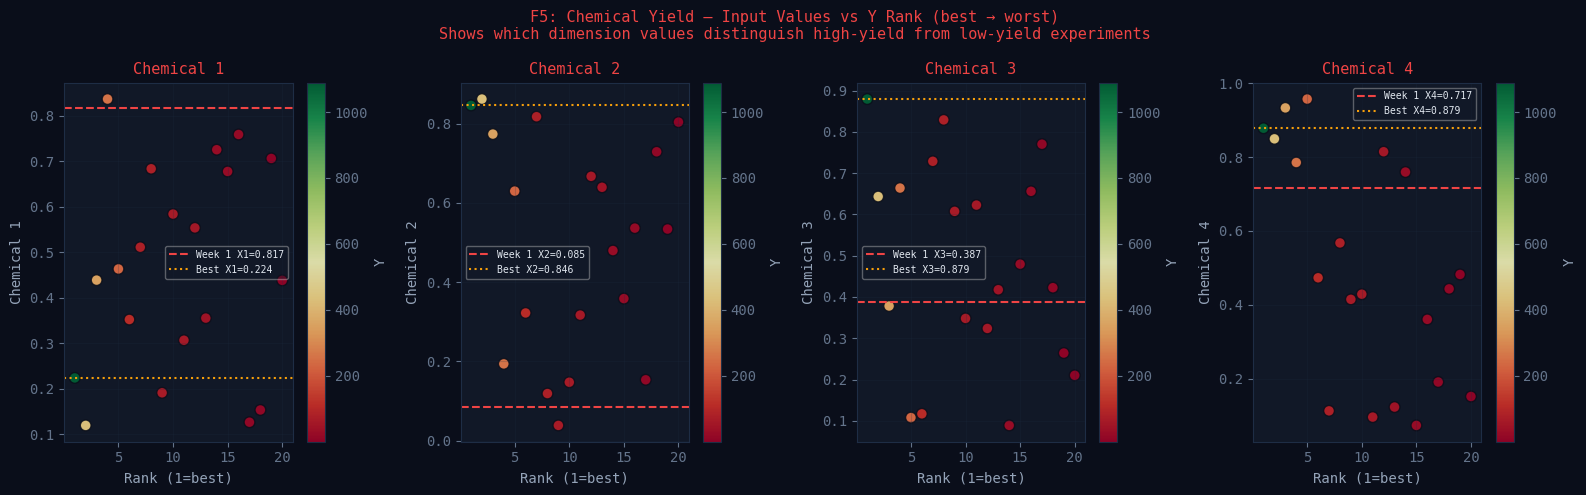


Best initial: [0.2242, 0.8465, 0.8795, 0.8785], Y=1088.86
Week 1:       [0.816816, 0.08509, 0.386806, 0.716711], Y=50.44

Conclusion: Chemical 1 should be LOW (best≈0.22, W1 used 0.817)
            Chemicals 2-4 should be HIGH (best≈0.85-0.88, W1 used 0.085/0.387/0.717)


In [ ]:
d5 = data['function_5']
X5, Y5 = d5['inputs'], d5['outputs']
labels5 = ['Chemical 1', 'Chemical 2', 'Chemical 3', 'Chemical 4']
w1_5 = WEEK1[5]

# Sort by Y descending
order = np.argsort(Y5)[::-1]
X5_sorted = X5[order]
Y5_sorted = Y5[order]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('F5: Chemical Yield — Input Values vs Y Rank (best → worst)\n'
             'Shows which dimension values distinguish high-yield from low-yield experiments',
             fontsize=11, color='#ef4444')

for ax, (i, label) in zip(axes, enumerate(labels5)):
    ranks = np.arange(1, len(Y5_sorted) + 1)
    sc = ax.scatter(ranks, X5_sorted[:, i], c=Y5_sorted, cmap='RdYlGn',
                    s=60, alpha=0.85, edgecolors='#0a0e1a')
    # Week 1 marker
    ax.axhline(w1_5['X'][i], color='#ef4444', lw=1.5, ls='--', 
               label=f'Week 1 X{i+1}={w1_5["X"][i]:.3f}')
    # Best initial marker
    ax.axhline(X5_sorted[0, i], color='#f59e0b', lw=1.5, ls=':',
               label=f'Best X{i+1}={X5_sorted[0,i]:.3f}')
    ax.set_xlabel('Rank (1=best)')
    ax.set_ylabel(label)
    ax.set_title(label, color='#ef4444')
    ax.legend(fontsize=7, framealpha=0.4)
    ax.grid(True, alpha=0.2)
    plt.colorbar(sc, ax=ax, label='Y')

plt.tight_layout()
plt.savefig('05_f5_chemical_yield_dims.png', dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()

print(f'\nBest initial: {[round(v,4) for v in X5_sorted[0].tolist()]}, Y={Y5_sorted[0]:.2f}')
print(f'Week 1:       {w1_5["X"]}, Y={w1_5["Y"]:.2f}')
print(f'\nConclusion: Chemical 1 should be LOW (best≈0.22, W1 used {w1_5["X"][0]:.3f})')
print(f'            Chemicals 2-4 should be HIGH (best≈0.85-0.88, W1 used {w1_5["X"][1]:.3f}/{w1_5["X"][2]:.3f}/{w1_5["X"][3]:.3f})')

## 8. Week 2 Query Targets — Summary

Based on this analysis, the following targets are recommended for week 2 submissions.

In [9]:
week2_targets = {
    1: {'X': [0.15, 0.85],                                       'rationale': 'Top-left quadrant — unsampled. Systematic hotspot search.'},
    2: {'X': [0.75, 0.93],                                       'rationale': 'Exploit near initial best [0.703, 0.927]. EI ξ=0.01.'},
    3: {'X': [0.48, 0.65, 0.32],                                  'rationale': 'Near initial best. Nudge B higher (0.61→0.65) — W1 confirmed low-B is worse.'},
    4: {'X': [0.55, 0.38, 0.50, 0.18],                            'rationale': 'Exploit initial best neighbourhood. P4 lower (0.25→0.18).'},
    5: {'X': [0.18, 0.87, 0.90, 0.90],                            'rationale': 'Exploit initial best. C1 lower, C2/C3/C4 higher. Unimodal — aggressively exploit.'},
    6: {'X': [0.72, 0.10, 0.75, 0.72, 0.04],                      'rationale': 'Near initial best. Reduce Sugar (0.155→0.10) and Milk (0.056→0.04).'},
    7: {'X': [0.04, 0.52, 0.20, 0.25, 0.38, 0.80],                'rationale': 'Perturb initial best. Lower n_est, higher LR, higher regularisation.'},
    8: {'X': [0.03, 0.04, 0.05, 0.02, 0.38, 0.85, 0.50, 0.92],   'rationale': 'Push P1-P4 lower, keep P6/P8 high — consistent with initial best pattern.'},
}

print(f'{"Fn":<4} {"Recommended W2 Submission":<55} {"Rationale"}')
print('-' * 120)
for fn_id, t in week2_targets.items():
    x_str = str([round(v, 4) for v in t['X']])
    print(f'F{fn_id:<3} {x_str:<55} {t["rationale"]}')

Fn   Recommended W2 Submission                               Rationale
------------------------------------------------------------------------------------------------------------------------
F1   [0.15, 0.85]                                            Top-left quadrant — unsampled. Systematic hotspot search.
F2   [0.75, 0.93]                                            Exploit near initial best [0.703, 0.927]. EI ξ=0.01.
F3   [0.48, 0.65, 0.32]                                      Near initial best. Nudge B higher (0.61→0.65) — W1 confirmed low-B is worse.
F4   [0.55, 0.38, 0.5, 0.18]                                 Exploit initial best neighbourhood. P4 lower (0.25→0.18).
F5   [0.18, 0.87, 0.9, 0.9]                                  Exploit initial best. C1 lower, C2/C3/C4 higher. Unimodal — aggressively exploit.
F6   [0.72, 0.1, 0.75, 0.72, 0.04]                           Near initial best. Reduce Sugar (0.155→0.10) and Milk (0.056→0.04).
F7   [0.04, 0.52, 0.2, 0.25, 0.38, 0.8]       

---

## Key Conclusions

1. **All 8 week 1 submissions landed below the best known initial value.** Primary cause: initial `.npy` data was not yet integrated into the GP when suggestions were generated. Fixed for week 2.

2. **Function 5 has the largest opportunity** — the initial data contains Y=1088.86 but week 1 returned Y=50.44. The unimodal structure and clear initial best point make this the highest-priority function to exploit.

3. **Functions 1 is the hardest** — near-zero output everywhere in both initial data and week 1. The hotspot has not been found. Requires systematic exploration rather than GP-guided exploitation.

4. **Correlation analysis (Section 5)** confirms the direction of each dimension's effect and supports the MODEL_CARD strategies.

5. **Over-exploration was the dominant week 1 error** — 7 of 8 submissions moved substantially away from the best initial point, confirmed by the L2 distance analysis in Section 6.
